# 산학프로젝트
**제조 공정 품질 불량 예측**

# 02 EDA

- 데이터 구조 파악과 기록 오류 확인
- 대상 데이터: `labeled_data.csv`, `unlabeled_data.csv`
- Output: `data/labeled_modeling.csv`(03 이후 노트북은 이 파일을 사용)
- 예측 서버는 같은 보정 규칙을 `dashboard/backend/app/corrections.py`에 따로 두고 실시간 입력 1건에 적용

## import

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns
import math
import pingouin as pg

plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 경로설정

In [2]:
os.chdir("data")

In [3]:
os.listdir()

['03_Baseline_Modeling_Result.csv',
 '04_1_1_Split_Structure_baseline.csv',
 '04_1_1_Split_Structure_group_cv.csv',
 '04_1_1_Split_Structure_identify.csv',
 '04_1_1_Split_Structure_importance.csv',
 '04_1_1_Split_Structure_split_seed.csv',
 '04_1_1_Split_Structure_train_size.csv',
 '04_1_Imbalance_and_Feature_Experiments.csv',
 '04_2_GridSearchCV.csv',
 '04_2_GridSearchCV_oof_candidates.csv',
 '04_2_GridSearchCV_oof_proba.csv',
 '04_2_GridSearchCV_oof_topk.csv',
 '04_2_GridSearchCV_xgb_variants.csv',
 '04_3_PCA.csv',
 '04_4_Feature_Selection.csv',
 '04_5_AutoEncoder_GridSearch.csv',
 '04_6_AutoEncoder_CV_Validation_folds.csv',
 '04_6_AutoEncoder_CV_Validation_oof_proba.csv',
 '04_6_AutoEncoder_CV_Validation_summary.csv',
 '04_6_AutoEncoder_CV_Validation_topk.csv',
 '04_6_AutoEncoder_CV_Validation_topk_summary.csv',
 '05_Operating_Point_best_model.csv',
 '05_Operating_Point_by_ratio.csv',
 '05_Operating_Point_daily.csv',
 '05_Operating_Point_threshold.csv',
 '07_1_Episode_Detection_by_r

## 데이터 불러오기

In [4]:
labeled=pd.read_csv('labeled_data.csv') # 불량 선별 여부 포함 데이터(지도학습용)
unlabeled=pd.read_csv('unlabeled_data.csv') # 불량 선별 여부 불포함 데이터(준지도학습용)

## EDA

In [5]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

## 기록 오류 확인 대상

- 결측·중복·고정값과 달리 **값 자체가 물리적으로 성립하지 않는** 경우
- 컬럼명이 단위를 정확히 말해주지 않으므로(`Average_Screw_RPM`, `Max_Screw_RPM`은 RPM이 아니라 mm/s) **컬럼 쌍 사이의 물리 관계**가 유일하게 믿을 수 있는 검사 수단
- 모델링과 같은 데이터로 보기 위해 **중복 제거 후 예측 대상인 CN7·RG3만** 남겨서 확인

## labeled_data.csv

In [6]:
labeled.shape

(7996, 45)

### 결측치 확인

In [7]:
info_df(labeled)

,Columns,Non-Null Count,Dtype
0,_id,7996,str
1,TimeStamp,7996,str
2,PART_FACT_PLAN_DATE,7996,str
3,PART_FACT_SERIAL,7996,int64
4,PART_NAME,7996,str
5,EQUIP_CD,7996,str
6,EQUIP_NAME,7996,str
7,PassOrFail,7996,str
8,Reason,71,str
9,Injection_Time,7996,float64


**Reason: 불량 유형**
- 불량으로 확인된 제품에만 기록됨

### 중복값 확인

In [8]:
labeled[labeled.duplicated(keep=False)].sort_values(by='_id')[:4].T

,2394,5232,5233,2395
_id,5f97659b9c0189cc668ea68e,5f97659b9c0189cc668ea68e,5f9765ef9c0189cc668ea838,5f9765ef9c0189cc668ea838
TimeStamp,2020-10-27 00:10:40,2020-10-27 00:10:40,2020-10-27 00:11:38,2020-10-27 00:11:38
PART_FACT_PLAN_DATE,2020-10-27 오전 12:00:00,2020-10-27 오전 12:00:00,2020-10-27 오전 12:00:00,2020-10-27 오전 12:00:00
PART_FACT_SERIAL,9,9,9,9
PART_NAME,CN7 W/S SIDE MLD'G LH,CN7 W/S SIDE MLD'G LH,CN7 W/S SIDE MLD'G LH,CN7 W/S SIDE MLD'G LH
EQUIP_CD,S14,S14,S14,S14
EQUIP_NAME,650톤-우진2호기,650톤-우진2호기,650톤-우진2호기,650톤-우진2호기
PassOrFail,Y,Y,Y,Y
Reason,NaN,NaN,NaN,NaN
Injection_Time,9.64,9.64,9.64,9.64


In [9]:
labeled.duplicated().sum()

np.int64(2764)

### 중복값 제거

In [10]:
labeled=labeled.drop_duplicates(keep='first', ignore_index=True)

### 품질 라벨 분포 확인 - 클래스 불균형 파악

In [11]:
labeled["PassOrFail"].value_counts()

PassOrFail
Y    5172
N      60
Name: count, dtype: int64

**불량(Fail)이 60건**으로 확인됨

In [12]:
labeled["PassOrFail"].value_counts(normalize=True)

PassOrFail
Y    0.988532
N    0.011468
Name: proportion, dtype: float64

**불량 비율이 5% 미만**으로 클래스 불균형이 심함

### PassOrFail 인코딩

In [13]:
labeled['PassOrFail']=labeled['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

### CN7, RG3 추출

In [14]:
labeled_cn7rg3=labeled[labeled['PART_NAME'].str.startswith(('CN7', 'RG3'))]
unlabeled_cn7rg3=unlabeled[unlabeled['PART_NAME'].str.startswith(('CN7', 'RG3'))]

print(f'labeled 전체 {len(labeled)}행 / CN7·RG3 {len(labeled_cn7rg3)}행')
print(f'unlabeled 전체 {len(unlabeled)}행 / CN7·RG3 {len(unlabeled_cn7rg3)}행')

labeled 전체 5232행 / CN7·RG3 5230행
unlabeled 전체 795315행 / CN7·RG3 125031행


### `Reason` — 라벨 누수

- 결측치 확인에서 본 `Reason`은 **불량으로 판정된 뒤에 기록되는 불량 사유**
- 예측 시점에는 존재할 수 없는 값이고, 값이 있다는 사실 자체가 불량이라는 뜻
- 입력에 넣으면 정답을 보고 맞히는 셈이므로 **입력에서 제외**

In [15]:
reason_by_label=labeled_cn7rg3.groupby('PassOrFail')['Reason'].agg(
    **{'행 수': 'size', '값이 있는 행': lambda s: s.notna().sum()})
print(reason_by_label)
print(f"\n불량 사유 종류: {labeled_cn7rg3['Reason'].dropna().unique().tolist()}")

             행 수  값이 있는 행
PassOrFail               
0           5170        0
1             60       60

불량 사유 종류: ['가스', '미성형', '초기허용불량']


### 이상치 확인

In [16]:
num_cols=labeled.select_dtypes(exclude="object").columns.tolist()
cat_cols=labeled.select_dtypes("str").columns.tolist()

print(f"수치형 변수: {num_cols}")
print(f"범주형 변수: {cat_cols}")

수치형 변수: ['PART_FACT_SERIAL', 'PassOrFail', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature', 'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3', 'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12']
범주형 변수: ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'Reason']


In [17]:
labeled[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PART_FACT_SERIAL,5232.0,11.814602,5.018760,2.000000,9.000000,10.000000,13.000000,24.000000
PassOrFail,5232.0,0.011468,0.106483,0.000000,0.000000,0.000000,0.000000,1.000000
Injection_Time,5232.0,7.531476,3.642040,1.050000,9.500000,9.540000,9.580000,16.309999
Filling_Time,5232.0,3.603219,1.503327,0.930000,4.380000,4.430000,4.470000,8.270000
Plasticizing_Time,5232.0,15.909851,1.694762,10.920000,16.540001,16.799999,16.920000,21.120001
Cycle_Time,5232.0,60.079708,1.003065,58.840000,59.520000,59.520000,59.670000,66.860001
Clamp_Close_Time,5232.0,7.039658,0.149487,5.160000,7.110000,7.120000,7.120000,7.180000
Cushion_Position,5232.0,653.510255,8.890390,11.100000,653.429993,653.440002,653.460022,655.080017
Switch_Over_Position,5232.0,0.502913,18.114641,0.000000,0.000000,0.000000,0.000000,655.309998
Plasticizing_Position,5232.0,64.852110,6.356800,53.549999,68.239998,68.339996,68.489998,68.860001


**Mold_Temperature**
- 3, 4를 제외한 변수에는 온도가 0으로 고정되어있음

In [18]:
labeled["Mold_Temperature_1"].value_counts()

Mold_Temperature_1
0.0    5232
Name: count, dtype: int64

In [19]:
labeled[cat_cols].describe().T

,count,unique,top,freq
_id,5232,5232,5f8928bb9c0189cc666ef19b,1
TimeStamp,5232,2625,2020-11-03 00:59:02,3
PART_FACT_PLAN_DATE,5232,13,2020-11-03 오전 12:00:00,927
PART_NAME,5232,6,CN7 W/S SIDE MLD'G RH,1989
EQUIP_CD,5232,3,S14,5230
EQUIP_NAME,5232,3,650톤-우진2호기,5230
Reason,60,3,가스,35


In [20]:
labeled['EQUIP_CD'].value_counts()

EQUIP_CD
S14    5230
S01       1
S12       1
Name: count, dtype: int64

**EQUIP_CD: 생산한 사출기 호기**
**EQUIP_NAME: 생산한 사출기 모델명**
- 99% 이상이 S14(650톤-우진2호기)에서 생산

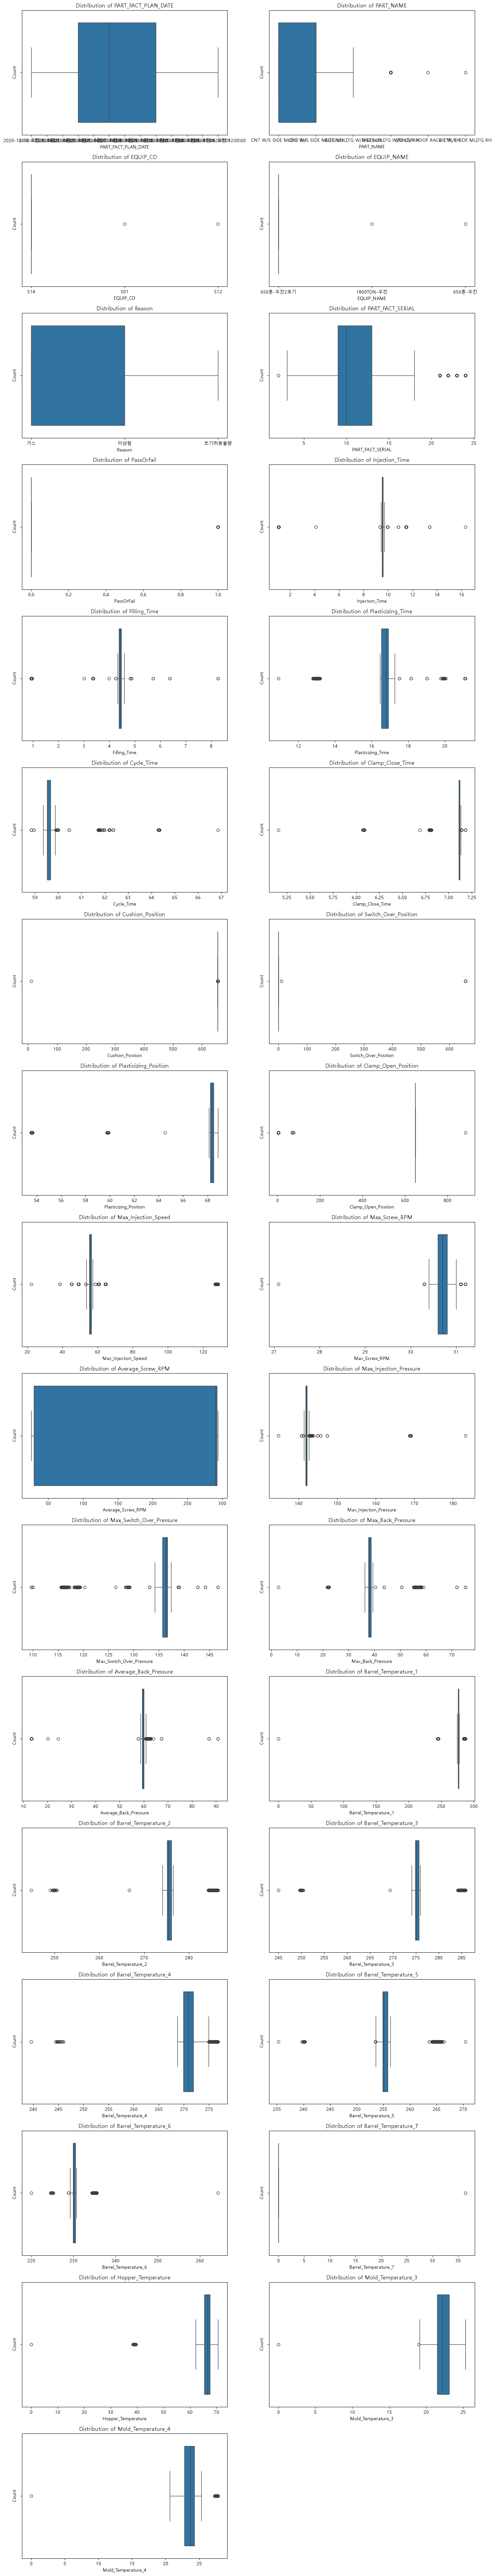

In [21]:
plot_col=cat_cols[2:] + num_cols[:26] + num_cols[28:30]
plt.figure(figsize=(15, 100))
for i, col in enumerate(plot_col): # id, timestamp 제외
    plt.subplot(22, 2, i+1)
    sns.boxplot(data=labeled, x=col)
    plt.tight_layout()
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")

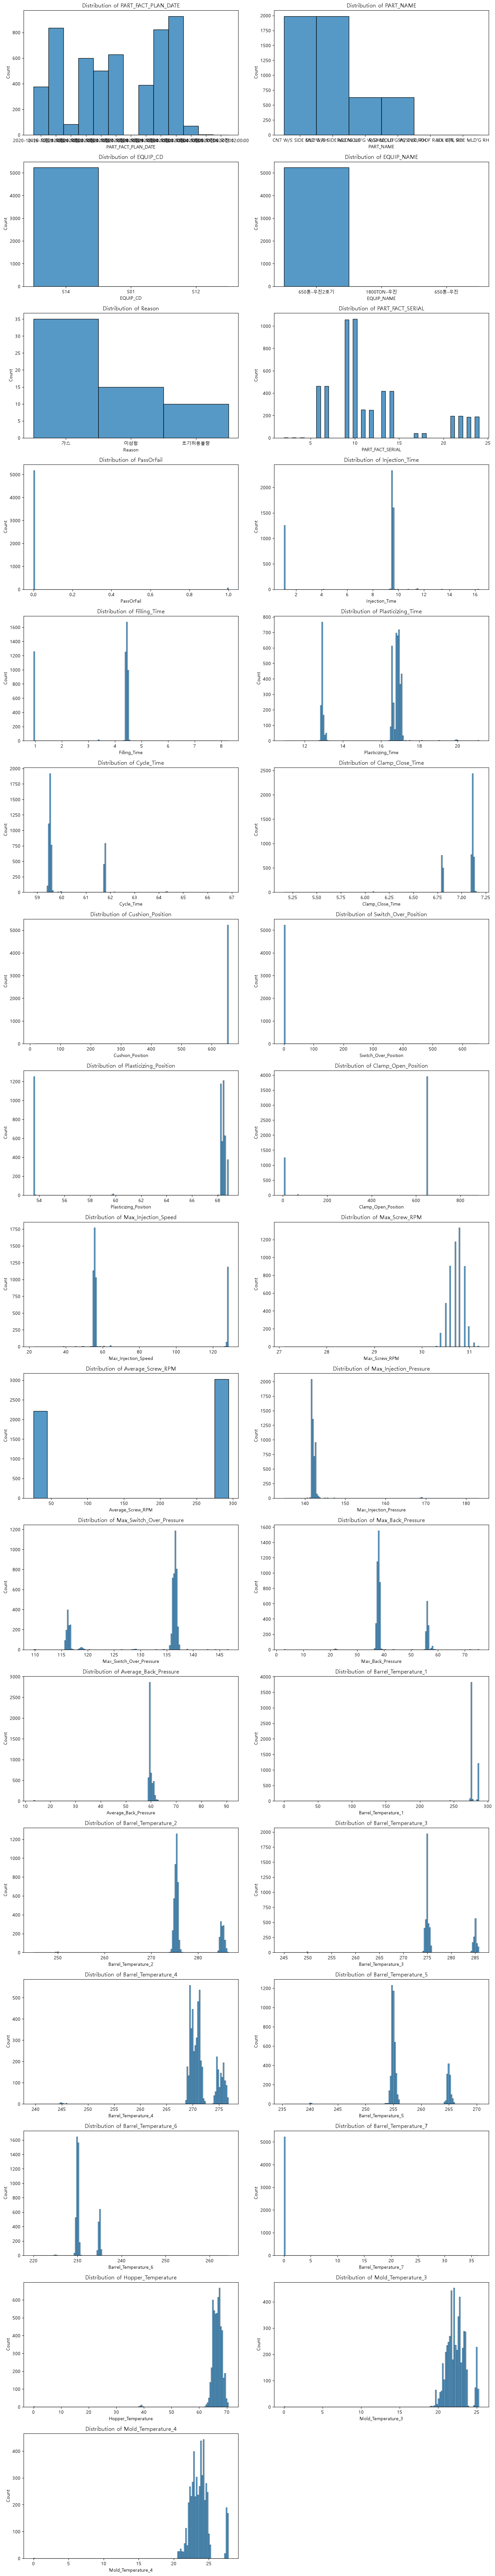

In [22]:
plot_col=cat_cols[2:] + num_cols[:26] + num_cols[28:30]
plt.figure(figsize=(15, 100))
for i, col in enumerate(plot_col): # id, timestamp 제외
    plt.subplot(22, 2, i+1)
    sns.histplot(data=labeled, x=col)
    plt.tight_layout()
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")

In [23]:
labeled['PART_NAME'].value_counts()

PART_NAME
CN7 W/S SIDE MLD'G RH        1989
CN7 W/S SIDE MLD'G LH        1985
RG3 MOLD'G W/SHLD, LH         628
RG3 MOLD'G W/SHLD, RH         628
SP2 CVR ROOF RACK CTR, RH       1
JX1 W/S SIDE MLD'G RH           1
Name: count, dtype: int64

**PART_NAME:제품의 이름**
- 99% 이상이 CN7, RG3 생산
- CN7, RG3을 생산하는 호기가 S14호일 것으로 추측

In [24]:
labeled['Barrel_Temperature_7'].value_counts()

Barrel_Temperature_7
0.000000     5231
36.400002       1
Name: count, dtype: int64

**Barrel_Temperature: 계량 및 사출 시 수지가 일정하게 용융(녹임)을 유지하기 위해 온도가 일정해야함**
- 7은 1건을 제외하고 0도로 고정

In [25]:
labeled['Switch_Over_Position'].value_counts()

Switch_Over_Position
0.000000      5227
655.309998       4
10.000000        1
Name: count, dtype: int64

**Switch_Over_Position: 고압, 보압절환위치(고압(사출압)에서 보압으로 진행될 때의 위치)**
- 대부분 0mm

In [26]:
labeled['Cushion_Position'].value_counts()

Cushion_Position
653.429993    1256
653.440002    1008
653.409973     763
653.419983     520
654.260010     349
653.450012     327
654.250000     322
654.239990     262
654.270020     174
654.229980      72
653.460022      70
654.280029      54
655.000000      18
654.219971      17
653.400024       6
654.210022       4
654.289978       2
653.630005       2
653.469971       2
653.390015       2
11.100000        1
655.080017       1
Name: count, dtype: int64

**Cushion_Position: 보압(사출압의 다음으로 가해지는 압력(금형 내부 압력을 조절하여 과충전을 방지))을 하기 위한 스크류의 위치**
- 대부분 653mm 이상
- 1건 11mm

#### 고정값 컬럼

- 위에서 개별로 확인한 고정값·결측 성격 컬럼을 한번에 모아 확인
- 최빈값 비율이 99%를 넘으면 분산이 없어 모델에 정보를 주지 못함
- **입력에서 제외**

In [27]:
const_check=[]
for c in labeled_cn7rg3.select_dtypes(exclude='object').columns:
    if c=='PassOrFail': # 타겟 제외
        continue
    s=labeled_cn7rg3[c].dropna()
    if len(s)==0:
        continue
    top_ratio=s.value_counts(normalize=True).iloc[0]
    if top_ratio>0.99:
        const_check.append({'컬럼': c, '최빈값': s.value_counts().index[0],
                            '최빈값 비율': round(top_ratio, 4), '고유값 수': s.nunique()})

pd.DataFrame(const_check).sort_values('최빈값 비율', ascending=False)

,컬럼,최빈값,최빈값 비율,고유값 수
1,Barrel_Temperature_7,0.0,1.0000,1
2,Mold_Temperature_1,0.0,1.0000,1
3,Mold_Temperature_2,0.0,1.0000,1
4,Mold_Temperature_5,0.0,1.0000,1
8,Mold_Temperature_9,0.0,1.0000,1
5,Mold_Temperature_6,0.0,1.0000,1
6,Mold_Temperature_7,0.0,1.0000,1
7,Mold_Temperature_8,0.0,1.0000,1
10,Mold_Temperature_11,0.0,1.0000,1
9,Mold_Temperature_10,0.0,1.0000,1


#### `Average_Screw_RPM` 10배 기록 스케일

- `Average_Screw_RPM`과 `Max_Screw_RPM`은 같은 물리량(스크류 속도, mm/s)의 평균과 최대이므로 **`Average` ≤ `Max`** 가 반드시 성립해야 함
- 그런데 labeled의 절반 이상에서 평균이 최대보다 큼

In [28]:
screw=labeled_cn7rg3[['TimeStamp', 'Average_Screw_RPM', 'Max_Screw_RPM']].copy()
screw['date']=pd.to_datetime(screw['TimeStamp']).dt.date
screw['ratio']=screw['Average_Screw_RPM']/screw['Max_Screw_RPM']

print(f"Average > Max 인 행: {(screw['Average_Screw_RPM']>screw['Max_Screw_RPM']).sum()} / {len(screw)}")

# 값 크기로 두 블록이 갈린다
screw['block']=np.where(screw['Average_Screw_RPM']>100, '290 단위', '29 단위')
block_summary=screw.groupby('block').agg(**{
    '행 수': ('ratio', 'size'),
    '시작일': ('date', 'min'),
    '종료일': ('date', 'max'),
    'Average 최소': ('Average_Screw_RPM', 'min'),
    'Average 최대': ('Average_Screw_RPM', 'max'),
    'Average/Max 평균': ('ratio', 'mean'),
    'Average/Max 표준편차': ('ratio', 'std'),
})
block_summary.round(4)

Average > Max 인 행: 3021 / 5230


,행 수,시작일,종료일,Average 최소,Average 최대,Average/Max 평균,Average/Max 표준편차
block,,,,,,,
29 단위,2209,2020-10-29,2020-11-06,29.0,29.4,0.9519,0.0051
290 단위,3021,2020-10-16,2020-10-27,290.4,293.9,9.4787,0.0616


- 두 블록의 `Average / Max` 비율이 **정확히 10배** 차이남(9.48 vs 0.95)
- `Max_Screw_RPM`은 전 기간 30.3 ~ 31.2 mm/s로 동일하므로 어긋난 쪽은 **`Average_Screw_RPM`**

In [29]:
print('Max_Screw_RPM 범위 (블록별)')
print(screw.groupby('block')['Max_Screw_RPM'].agg(['min', 'max']).round(2))

# 보정: 100을 넘으면 10으로 나눈다
fixed=screw.copy()
fixed['Average_Screw_RPM']=np.where(fixed['Average_Screw_RPM']>100,
                                    fixed['Average_Screw_RPM']/10, fixed['Average_Screw_RPM'])
fixed['ratio']=fixed['Average_Screw_RPM']/fixed['Max_Screw_RPM']

print(f"\n보정 후 Average > Max 인 행: {(fixed['Average_Screw_RPM']>fixed['Max_Screw_RPM']).sum()} / {len(fixed)}")
print('보정 후 Average/Max 비율 (블록별)')
print(fixed.groupby('block')['ratio'].agg(['mean', 'std']).round(4))

Max_Screw_RPM 범위 (블록별)
         min   max
block             
29 단위   30.3  31.1
290 단위  30.4  31.2

보정 후 Average > Max 인 행: 0 / 5230
보정 후 Average/Max 비율 (블록별)
          mean     std
block                 
29 단위   0.9519  0.0051
290 단위  0.9479  0.0062


- 보정 후 두 블록의 비율이 0.948과 0.952로 일치하고 위반 행이 0
- **실제 스크류 속도는 전 기간 약 29 mm/s로 같았고, 10-27 이전 구간이 10배로 기록**
- 계량시간(`Plasticizing_Time`)과 계량위치(`Plasticizing_Position`)가 두 블록에서 같다는 점도 이 해석과 일치

In [30]:
check=labeled_cn7rg3.copy()
check['block']=np.where(check['Average_Screw_RPM']>100, '290 단위', '29 단위')
check[check['PART_NAME'].str.startswith('CN7')].groupby('block')[
    ['Plasticizing_Time', 'Plasticizing_Position']].mean().round(2)

,Plasticizing_Time,Plasticizing_Position
block,,
29 단위,16.76,68.26
290 단위,16.95,68.59


- **unlabeled 데이터는 전 구간이 잘못된 스케일** — 29 단위 값이 하나도 없음
- 실시간 예측에서 보정하지 않으면 학습 분포와 10배 어긋난 값이 모델에 들어감

In [31]:
u_screw=unlabeled_cn7rg3[['Average_Screw_RPM', 'Max_Screw_RPM']].dropna()
u_nonzero=u_screw[u_screw['Average_Screw_RPM']>0]

print(f'unlabeled Average_Screw_RPM 범위: {u_nonzero["Average_Screw_RPM"].min():.1f} ~ {u_nonzero["Average_Screw_RPM"].max():.1f}')
print(f'  이 중 100 이하(정상 스케일) 행: {(u_nonzero["Average_Screw_RPM"]<=100).sum()}건')
print(f'보정 전 Average > Max 인 행: {(u_nonzero["Average_Screw_RPM"]>u_nonzero["Max_Screw_RPM"]).sum()} / {len(u_nonzero)}')

u_fixed=np.where(u_nonzero['Average_Screw_RPM']>100, u_nonzero['Average_Screw_RPM']/10, u_nonzero['Average_Screw_RPM'])
print(f'보정 후 Average > Max 인 행: {(u_fixed>u_nonzero["Max_Screw_RPM"]).sum()} / {len(u_nonzero)}')

unlabeled Average_Screw_RPM 범위: 196.5 ~ 379.7
  이 중 100 이하(정상 스케일) 행: 0건
보정 전 Average > Max 인 행: 71091 / 71091
보정 후 Average > Max 인 행: 0 / 71091


#### `Average_Back_Pressure` > `Max_Back_Pressure`

- 배압도 같은 물리량의 평균과 최대이므로 평균이 최대를 넘을 수 없음
- Screw_RPM과 달리 **어느 컬럼이 평균이고 어느 쪽이 최대인지 알 수 없음** — 스케일 문제가 아니라 두 컬럼이 뒤바뀐 형태
- 순서만 모를 뿐 {평균, 최대}라는 약한 가정만 사용해 **행별로 작은 값을 Average, 큰 값을 Max로 재배치**(측정값은 버리지 않음)

In [32]:
for name, df in [('labeled', labeled_cn7rg3), ('unlabeled', unlabeled_cn7rg3)]:
    pair=df[['Average_Back_Pressure', 'Max_Back_Pressure']].dropna()
    violation=(pair['Average_Back_Pressure']>pair['Max_Back_Pressure']).sum()
    print(f'{name}: Average > Max 인 행 {violation} / {len(pair)} ({violation/len(pair):.1%})')

labeled: Average > Max 인 행 5212 / 5230 (99.7%)
unlabeled: Average > Max 인 행 52321 / 125031 (41.8%)


#### 센서 결측이 0으로 기록

- 사출 중 스크류 속도나 배럴 온도가 0일 수 없으므로 0은 값이 아니라 **수집 실패**
- unlabeled에서 특히 많음

In [33]:
sensor_cols=['Max_Screw_RPM', 'Average_Screw_RPM', 'Average_Back_Pressure',
             'Barrel_Temperature_1', 'Mold_Temperature_3', 'Mold_Temperature_4']

zero_rows=[]
for name, df in [('labeled', labeled_cn7rg3), ('unlabeled', unlabeled_cn7rg3)]:
    present=[c for c in sensor_cols if c in df.columns]
    row={'데이터': name, '전체 행': len(df)}
    for c in present:
        row[c]=int((df[c]==0).sum())
    row['하나라도 0인 행']=int((df[present]==0).any(axis=1).sum())
    zero_rows.append(row)

pd.DataFrame(zero_rows).set_index('데이터').T

데이터,labeled,unlabeled
전체 행,5230,125031
Max_Screw_RPM,0,53940
Average_Screw_RPM,0,53940
Average_Back_Pressure,0,53940
Barrel_Temperature_1,0,53928
Mold_Temperature_3,0,53928
Mold_Temperature_4,0,53928
하나라도 0인 행,0,53940


- **결측 행은 보정 대상이 아니라 예측 제외 대상**
- 0을 다른 값으로 채우면 없는 측정을 지어내는 것이므로, 예측 서버는 이런 행을 `예측 불가`로 표시

### 상관관계 확인

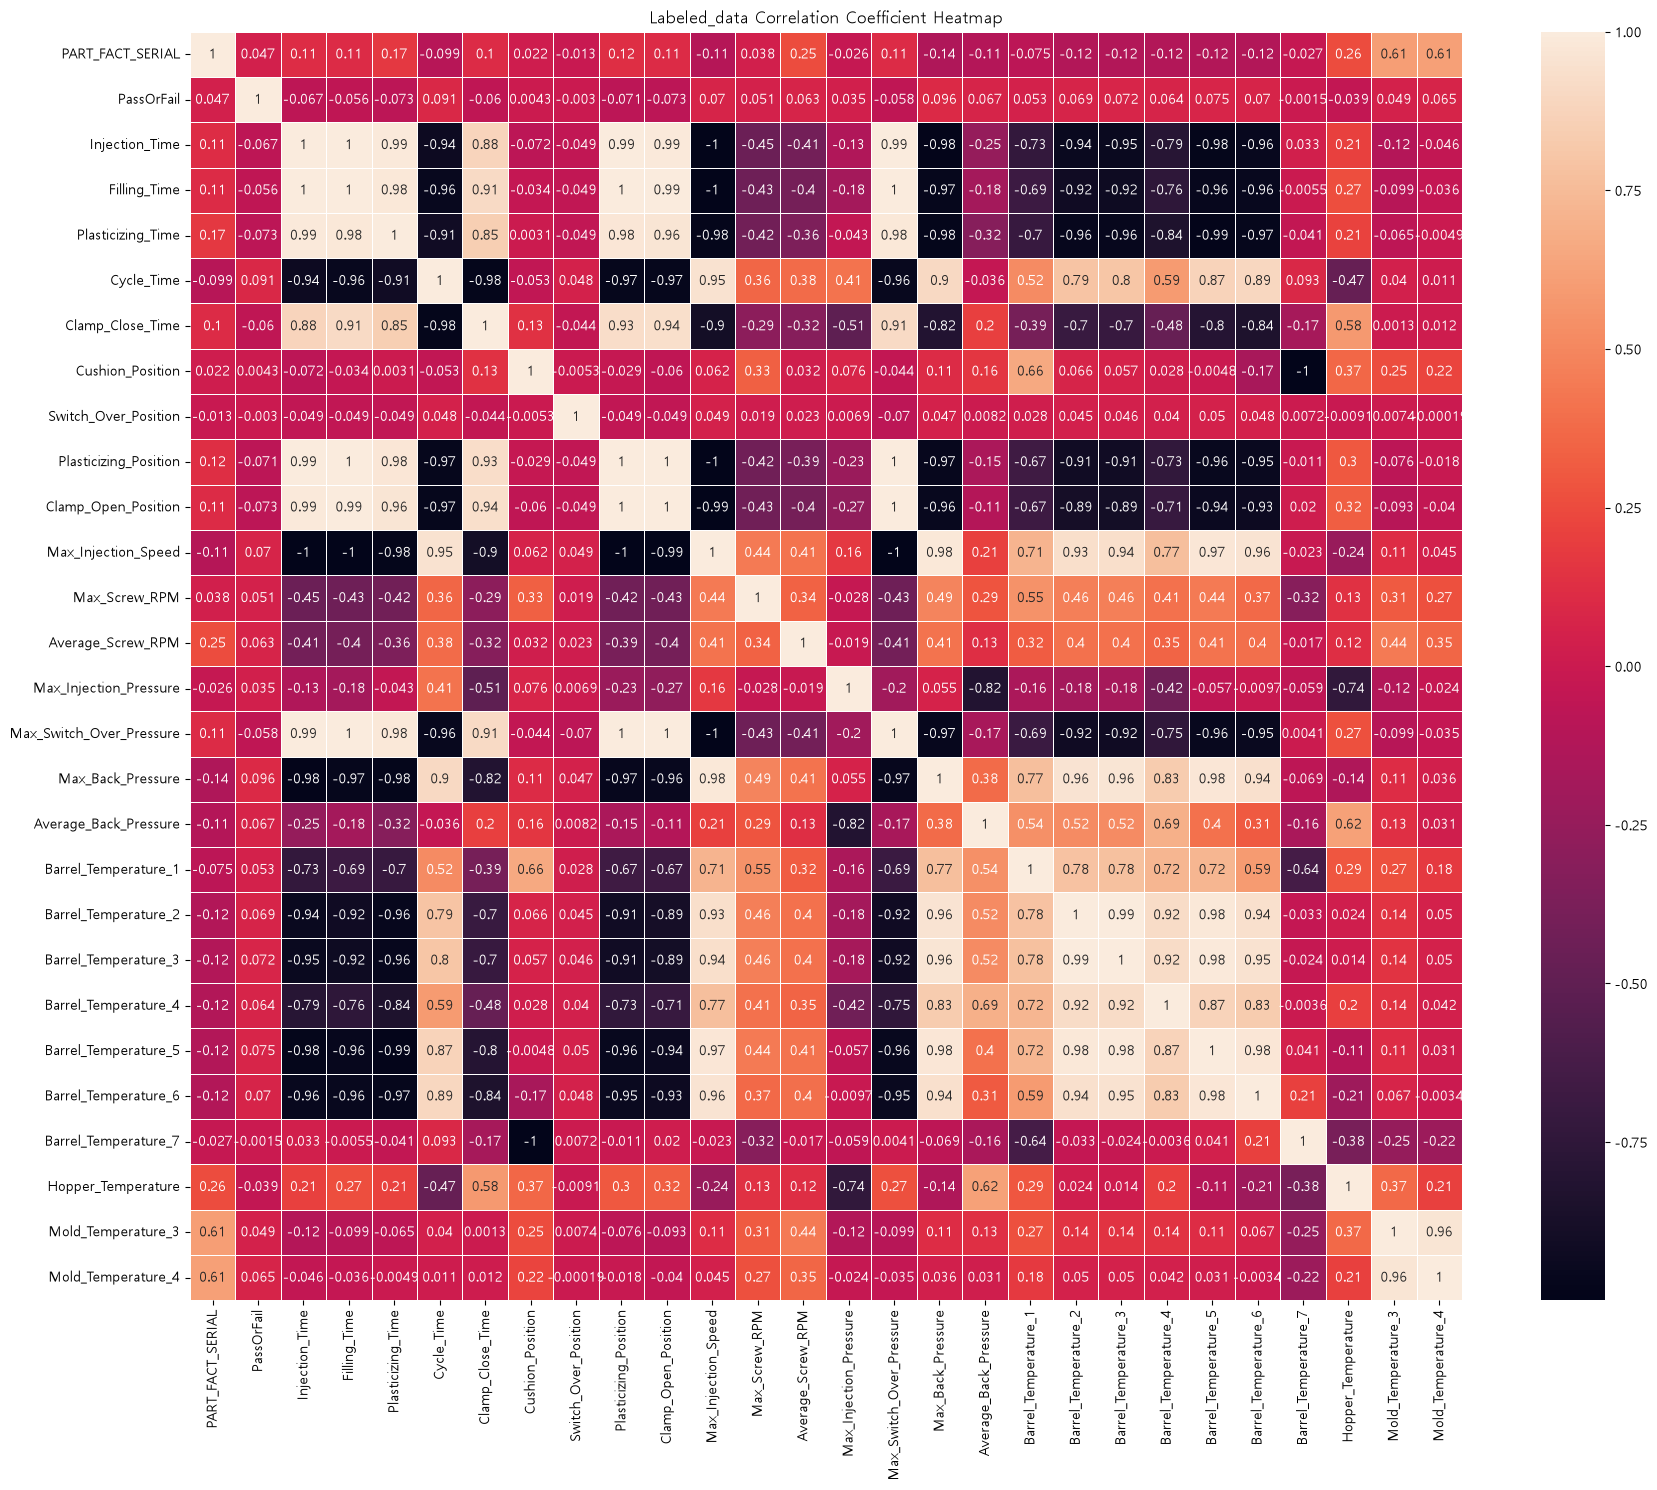

In [34]:
# Nan값 있는 컬럼 제외 후 확인
corr=pd.DataFrame(labeled[num_cols[:26] + num_cols[28:30]].corr())

fig, ax=plt.subplots(1, 1, figsize=(18, 15))

sns.heatmap(corr, annot=True, linewidths=0.5, annot_kws={'size':10})
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title('Labeled_data Correlation Coefficient Heatmap')
plt.tight_layout()
plt.show()

In [35]:
pd.DataFrame(labeled.corr(numeric_only=True)["PassOrFail"].sort_values(ascending=False))

,PassOrFail
PassOrFail,1.000000
Max_Back_Pressure,0.096172
Cycle_Time,0.091204
Barrel_Temperature_5,0.075008
Barrel_Temperature_3,0.072159
Barrel_Temperature_6,0.070144
Max_Injection_Speed,0.070004
Barrel_Temperature_2,0.069232
Average_Back_Pressure,0.067491
Mold_Temperature_4,0.065202


**양의 상관관계**
- Max_Back_Pressure(0.0962): 수지가 계량이 되는 중에 스크류가 밀려나는 현상을 저지하기 위한 최대 압력
- Cycle_Time(0.0912): 1번의 제품 생산에 소요되는 생산시간

**음의 상관관계**
- Clamp_Open_Position(-0.0729): 제품이 생산되어 추출하기 위해 금형이 열리고 난 위치
- Plasticizing_Time(-0.0726): 계량 시간으로 재료를 스크류에 1번 생산할 만큼 용융되어 저장되는 시간
- Plasticizing_Position(-0.0711): 계량 완료 위치(계량을 마친 스크류 위치)

- 상관계수가 ±0.1보다 작아 수치상 상관이 낮아 보이므로, 해당 변수에 대해 추가 검정을 진행함

### Mann-Whitney U Test

In [36]:
pass_group=labeled[labeled['PassOrFail']==0]['Max_Back_Pressure']
fail_group=labeled[labeled['PassOrFail']==1]['Max_Back_Pressure']

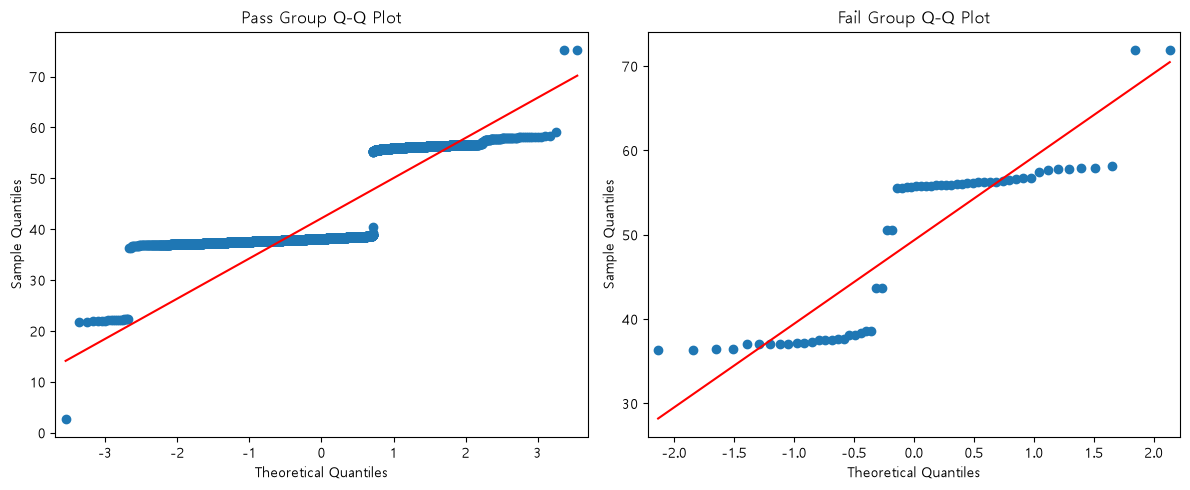

In [37]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 정상 그룹 Q-Q Plot
sm.qqplot(pass_group, line='s', ax=axes[0])
axes[0].set_title('Pass Group Q-Q Plot')

# 불량 그룹 Q-Q Plot
sm.qqplot(fail_group, line='s', ax=axes[1])
axes[1].set_title('Fail Group Q-Q Plot')

plt.tight_layout()
plt.show()

데이터가 기준선에서 확연히 벗어난 형태로 정규성을 만족하지 않음을 확인
- 비모수검정(Mann-Whitney U test) 적용

In [38]:
from scipy import stats

stat, p_value=stats.mannwhitneyu(pass_group, fail_group)

print(f'p-value: {p_value:.30f}')

p-value: 0.000239815206005845215535624004


**p-value<0.05**로, `Max_Back_Pressure`에 따라 불량 여부에 통계적으로 유의미한 차이가 있음

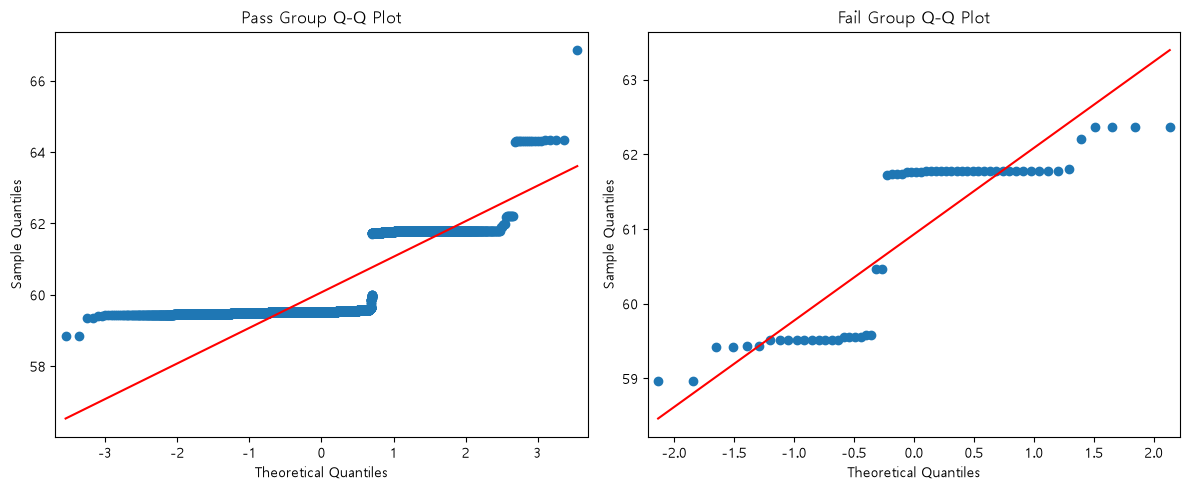

In [39]:
pass_group=labeled[labeled['PassOrFail']==0]['Cycle_Time']
fail_group=labeled[labeled['PassOrFail']==1]['Cycle_Time']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 정상 그룹 Q-Q Plot
sm.qqplot(pass_group, line='s', ax=axes[0])
axes[0].set_title('Pass Group Q-Q Plot')

# 불량 그룹 Q-Q Plot
sm.qqplot(fail_group, line='s', ax=axes[1])
axes[1].set_title('Fail Group Q-Q Plot')

plt.tight_layout()
plt.show()

In [40]:
stat, p_value=stats.mannwhitneyu(pass_group, fail_group)

print(f'p-value: {p_value:.30f}')

p-value: 0.000000021165718918382713149029


**p-value<0.05**로, `Cycle_Time`에 따라 불량 여부에 통계적으로 유의미한 차이가 있음

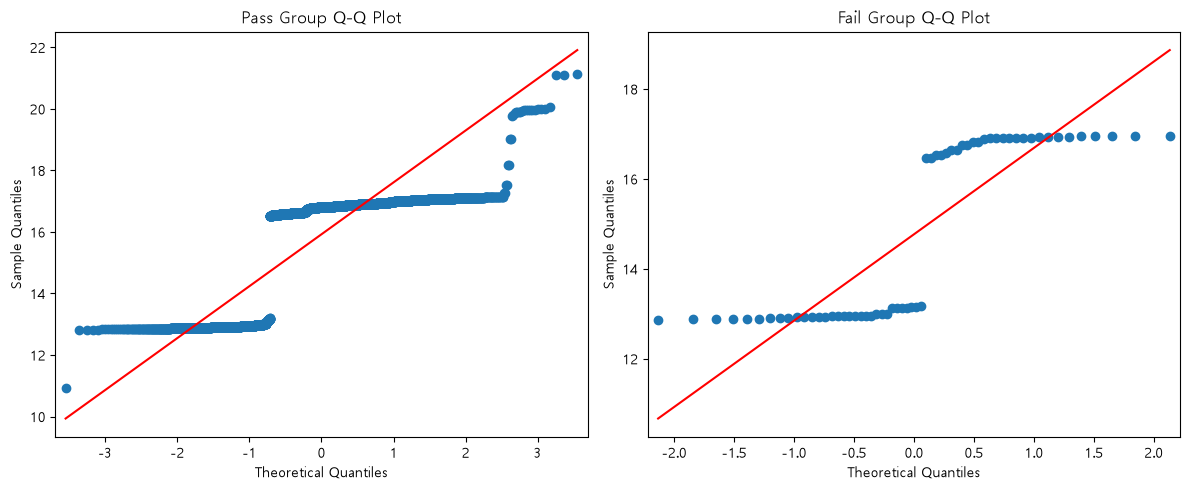

In [41]:
pass_group=labeled[labeled['PassOrFail']==0]['Plasticizing_Time']
fail_group=labeled[labeled['PassOrFail']==1]['Plasticizing_Time']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 정상 그룹 Q-Q Plot
sm.qqplot(pass_group, line='s', ax=axes[0])
axes[0].set_title('Pass Group Q-Q Plot')

# 불량 그룹 Q-Q Plot
sm.qqplot(fail_group, line='s', ax=axes[1])
axes[1].set_title('Fail Group Q-Q Plot')

plt.tight_layout()
plt.show()

In [42]:
stat, p_value=stats.mannwhitneyu(pass_group, fail_group)

print(f'p-value: {p_value:.30f}')

p-value: 0.000435662097065063036015891695


**p-value<0.05**로, `Plasticizing_Time`에 따라 불량 여부에 통계적으로 유의미한 차이가 있음

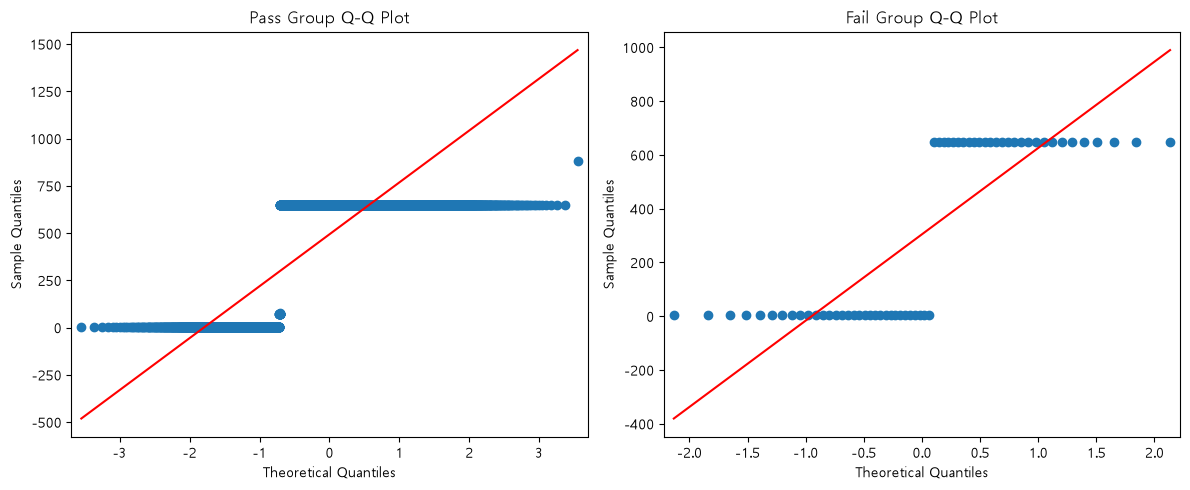

In [43]:
pass_group=labeled[labeled['PassOrFail']==0]['Clamp_Open_Position']
fail_group=labeled[labeled['PassOrFail']==1]['Clamp_Open_Position']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 정상 그룹 Q-Q Plot
sm.qqplot(pass_group, line='s', ax=axes[0])
axes[0].set_title('Pass Group Q-Q Plot')

# 불량 그룹 Q-Q Plot
sm.qqplot(fail_group, line='s', ax=axes[1])
axes[1].set_title('Fail Group Q-Q Plot')

plt.tight_layout()
plt.show()

In [44]:
stat, p_value=stats.mannwhitneyu(pass_group, fail_group)

print(f'p-value: {p_value:.30f}')

p-value: 0.000000123823988182686683387352


**p-value<0.05**로, `Clamp_Open_Position`에 따라 불량 여부에 통계적으로 유의미한 차이가 있음

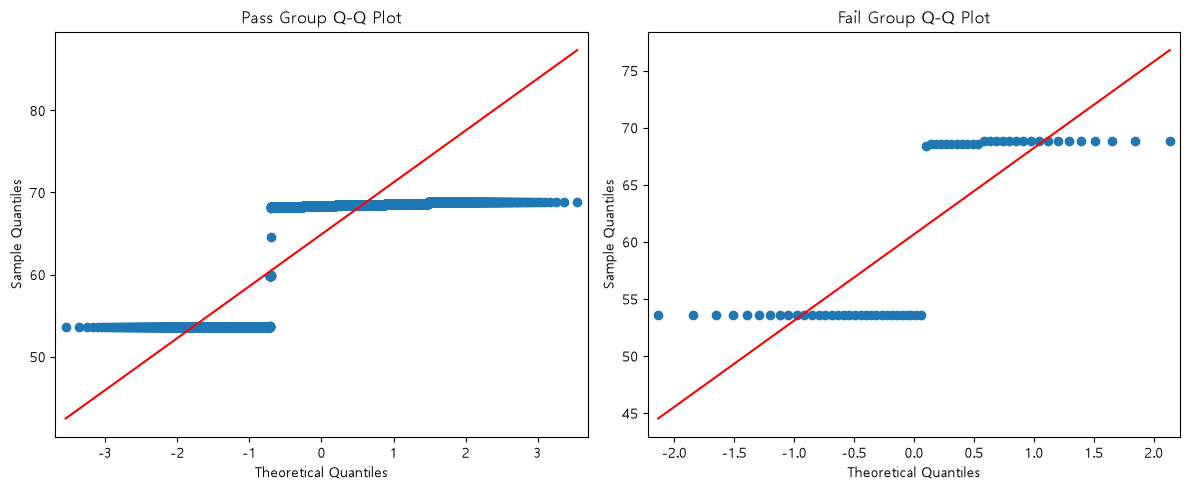

In [45]:
pass_group=labeled[labeled['PassOrFail']==0]['Plasticizing_Position']
fail_group=labeled[labeled['PassOrFail']==1]['Plasticizing_Position']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 정상 그룹 Q-Q Plot
sm.qqplot(pass_group, line='s', ax=axes[0])
axes[0].set_title('Pass Group Q-Q Plot')

# 불량 그룹 Q-Q Plot
sm.qqplot(fail_group, line='s', ax=axes[1])
axes[1].set_title('Fail Group Q-Q Plot')

plt.tight_layout()
plt.show()

In [46]:
stat, p_value=stats.mannwhitneyu(pass_group, fail_group)

print(f'p-value: {p_value:.30f}')

p-value: 0.948775661224470101551276002283


**p-value>0.05**로, `Plasticizing_Position`에 따라 불량 여부에 통계적으로 유의미한 차이가 없음
- 상관관계가 -0.07임에도 통계적으로 유의미하지 않다는 결과가 나옴에 따라 모든 변수에 대해 확인할 필요가 있음

In [47]:
# 유의미한 변수를 담을 리스트
results = []

# 1. 모든 수치형 변수에 대해 비모수 검정(Mann-Whitney U) 자동화
numeric_cols = labeled.select_dtypes(include=['number']).columns
numeric_cols = [col for col in numeric_cols if col != 'PassOrFail']  # 타겟 변수 제외

for col in numeric_cols:
    pass_data = labeled[labeled['PassOrFail'] == 0][col].dropna()
    fail_data = labeled[labeled['PassOrFail'] == 1][col].dropna()

    # Mann-Whitney U test 진행
    stat, p_val = stats.mannwhitneyu(pass_data, fail_data)

    # 피어슨 상관계수도 함께 계산
    corr = labeled[col].corr(labeled['PassOrFail'])

    # mwu 계산
    mwu = pg.mwu(pass_data, fail_data)

    results.append(
        {
            'Variable': col,
            'Correlation': corr,
            'p_value': p_val,
            'RBC': mwu['RBC'].item(), # Rank-Biserial Correlation (효과 크기)
            'CLES': mwu['CLES'].item(), # Common Language Effect Size, 정상 데이터와 불량 데이터에서 각각 하나씩 무작위로 추출했을 때, 불량 데이터의 수치가 더 크거나 작을 확률
            'Is_Significant': p_val < 0.05,  # 유의미 여부 (True/False)
        }
    )

# 2. 데이터프레임으로 변환 후 p-value 기준 오름차순 정렬
res_df = pd.DataFrame(results).sort_values(by='p_value')

# 3. 통계적으로 유의미한(p < 0.05) 핵심 변수만 필터링해서 보기
significant_vars = res_df[res_df['Is_Significant'] == True]
print(f"총 {len(numeric_cols)}개 변수 중 유의미한 변수 {len(significant_vars)}개")
display(significant_vars)

총 37개 변수 중 유의미한 변수 21개


C:\Users\subin\miniconda3\envs\kmu_project\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\subin\miniconda3\envs\kmu_project\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,Variable,Correlation,p_value,RBC,CLES,Is_Significant
4,Cycle_Time,0.091204,2.116572e-08,-0.409464,0.295268,True
9,Clamp_Open_Position,-0.072868,1.238240e-07,0.295050,0.647525,True
21,Barrel_Temperature_5,0.075008,1.280473e-07,-0.394754,0.302623,True
19,Barrel_Temperature_3,0.072159,4.435632e-07,-0.376892,0.311554,True
24,Hopper_Temperature,-0.038702,1.257045e-06,0.363257,0.681629,True
13,Max_Injection_Pressure,0.034674,1.557089e-06,-0.356519,0.321740,True
20,Barrel_Temperature_4,0.063927,3.143504e-06,-0.349356,0.325322,True
16,Average_Back_Pressure,0.067491,2.456190e-05,-0.315420,0.342290,True
11,Max_Screw_RPM,0.050748,5.124338e-05,-0.297664,0.351168,True
15,Max_Back_Pressure,0.096172,2.398152e-04,-0.275064,0.362468,True


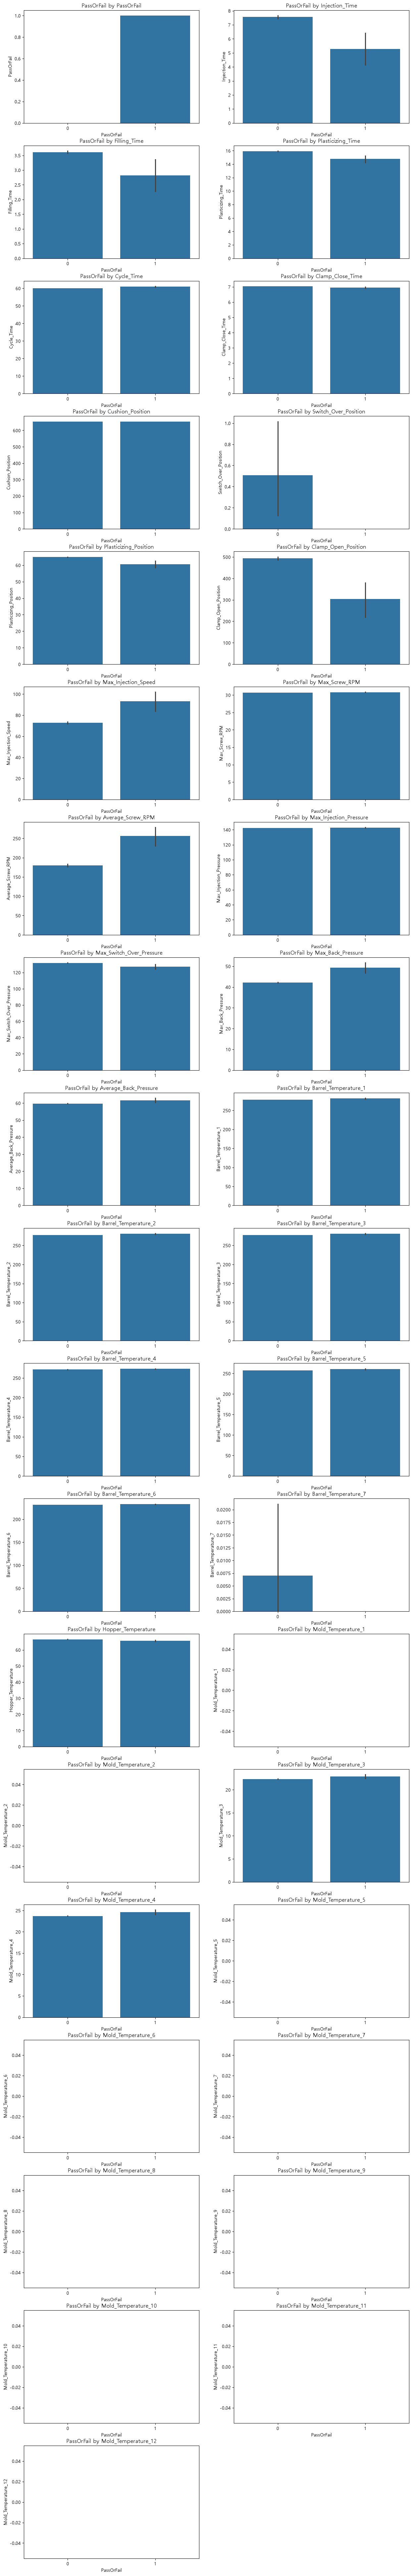

In [48]:
plt.figure(figsize=(15, 100))
for i, col in enumerate(num_cols[1:]):
    plt.subplot(19, 2, i+1)
    sns.barplot(data=labeled, x="PassOrFail", y=col)
    plt.title(f"PassOrFail by {col}")
    plt.xlabel("PassOrFail")
    plt.ylabel(col)

plt.show()

- Injection_Time
- Filling_Time
- Clamp_Open_Position
- Max_Injection_Speed
- Average_Screw_RPM
- Max_Back_Pressure

PassOrFail에 따라 평균에 차이가 있는 것으로 보임

### `Clamp_Open_Position` — 제품에 종속된 값

- Mann-Whitney U Test에서는 유의미했지만(p<0.05), labeled에서 사실상 3개 값만 가짐
- 제품(`PART_NAME`)이 정해지면 값이 정해지므로 **`Part` 변수 외에 추가 정보가 없음**
- unlabeled에서는 **학습에서 본 세 값 중 어느 것과도 다른 행이 76%**
- 남겨두면 모델에 처음 보는 값만 넣게 되므로 **입력에서 제외**

In [49]:
print('labeled Clamp_Open_Position 값 분포')
print(labeled_cn7rg3['Clamp_Open_Position'].value_counts())

trained_values=labeled_cn7rg3['Clamp_Open_Position'].dropna().unique()
u_clamp=unlabeled_cn7rg3['Clamp_Open_Position'].dropna()

# 부동소수점이므로 근사 일치로 비교한다
matched=np.zeros(len(u_clamp), dtype=bool)
for v in trained_values:
    matched |= np.isclose(u_clamp.to_numpy(), v)

print(f'\nunlabeled {len(u_clamp)}행 기준')
print(f'  학습에서 본 값과 다름: {(~matched).sum()} ({(~matched).mean():.1%})')
print(f'  학습 값 범위 {u_clamp.min():.2f} ~ {u_clamp.max():.2f} (학습: {trained_values.min():.2f} ~ {trained_values.max():.2f})')

# 제품군별로 보면 더 분명하다
u_fam=unlabeled_cn7rg3.assign(fam=unlabeled_cn7rg3['PART_NAME'].str[:3])
for fam, trained_value in [('CN7', 647.989990), ('RG3', 4.630000)]:
    g=u_fam[u_fam['fam']==fam]['Clamp_Open_Position'].dropna()
    diff=(~np.isclose(g.to_numpy(), trained_value)).sum()
    print(f'  {fam}: 학습값 {trained_value}와 다른 행 {diff} / {len(g)} ({diff/len(g):.1%})')

labeled Clamp_Open_Position 값 분포
Clamp_Open_Position
647.989990    3956
4.630000      1256
69.639999       18
Name: count, dtype: int64

unlabeled 125031행 기준
  학습에서 본 값과 다름: 95387 (76.3%)
  학습 값 범위 0.00 ~ 654.99 (학습: 4.63 ~ 647.99)
  CN7: 학습값 647.98999와 다른 행 37166 / 52547 (70.7%)
  RG3: 학습값 4.63와 다른 행 60137 / 72484 (83.0%)


## unlabeled_data.csv

In [50]:
unlabeled.shape

(795315, 45)

### 결측치 확인

In [51]:
info_df(unlabeled)

,Columns,Non-Null Count,Dtype
0,_id,795315,str
1,TimeStamp,795315,str
2,PART_FACT_PLAN_DATE,795315,str
3,PART_FACT_SERIAL,795315,int64
4,PART_NO,795315,str
5,PART_NAME,795315,str
6,EQUIP_CD,795315,str
7,EQUIP_NAME,795315,str
8,ERR_FACT_QTY,795315,int64
9,Injection_Time,795315,float64


### 중복값 확인

In [52]:
unlabeled[unlabeled.duplicated(keep=False)].sort_values(by='_id')

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NO,PART_NAME,EQUIP_CD,EQUIP_NAME,ERR_FACT_QTY,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12


- 중복값 없음

### 이상치 확인

In [53]:
num_cols=unlabeled.select_dtypes(exclude="object").columns.tolist()
cat_cols=unlabeled.select_dtypes("object").columns.tolist()

print(f"수치형 변수: {num_cols}")
print(f"범주형 변수: {cat_cols}")

수치형 변수: ['PART_FACT_SERIAL', 'ERR_FACT_QTY', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature', 'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3', 'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12']
범주형 변수: ['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_NO', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME']


C:\Users\subin\AppData\Local\Temp\ipykernel_35420\851644182.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=unlabeled.select_dtypes("object").columns.tolist()


In [54]:
unlabeled[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PART_FACT_SERIAL,795315.0,7.346591,6.070685,1.00,2.00,6.00,10.00,54.00
ERR_FACT_QTY,795315.0,13.862124,26.549459,0.00,1.00,5.00,13.00,353.00
Injection_Time,795315.0,9.454754,5.569126,0.13,5.00,9.52,16.29,29.10
Filling_Time,795315.0,3.897417,1.645200,0.00,2.95,3.35,5.00,29.10
Plasticizing_Time,795315.0,11.230021,7.619902,0.20,2.90,10.95,16.77,468.20
Cycle_Time,795315.0,58.030807,16.916262,0.00,39.10,64.42,67.59,648.39
Clamp_Close_Time,795315.0,5.575053,1.913712,2.11,3.40,6.08,6.72,30.10
Cushion_Position,795315.0,215.040085,296.933993,0.00,11.80,18.20,653.62,655.33
Switch_Over_Position,795315.0,10.884156,19.045073,0.00,0.00,10.00,18.20,655.34
Plasticizing_Position,795315.0,63.556493,40.963720,31.27,40.50,59.90,63.42,392.90


In [55]:
unlabeled[cat_cols].describe().T

,count,unique,top,freq
_id,795315,795315,5f9136166e37704af878240e,1
TimeStamp,795315,591556,2020-05-07 12:56:25,6
PART_FACT_PLAN_DATE,795315,209,2020-10-15 오전 12:00:00,13675
PART_NO,795315,81,87275Q5000,118071
PART_NAME,795315,81,"SP2 CVR ROOF RACK CTR, LH",118071
EQUIP_CD,795315,13,S01,278431
EQUIP_NAME,795315,13,1800TON-우진,278431


In [56]:
unlabeled['EQUIP_CD'].value_counts()

EQUIP_CD
S01    278431
S12    105360
S14     82970
S06     76818
S11     71076
S02     50794
S10     50266
S13     25692
S04     21415
S15     20616
S08      6383
S09      4987
S07       507
Name: count, dtype: int64

labeled 데이터셋과 달리 모델이 다양하지만, S01 모델 데이터가 많음

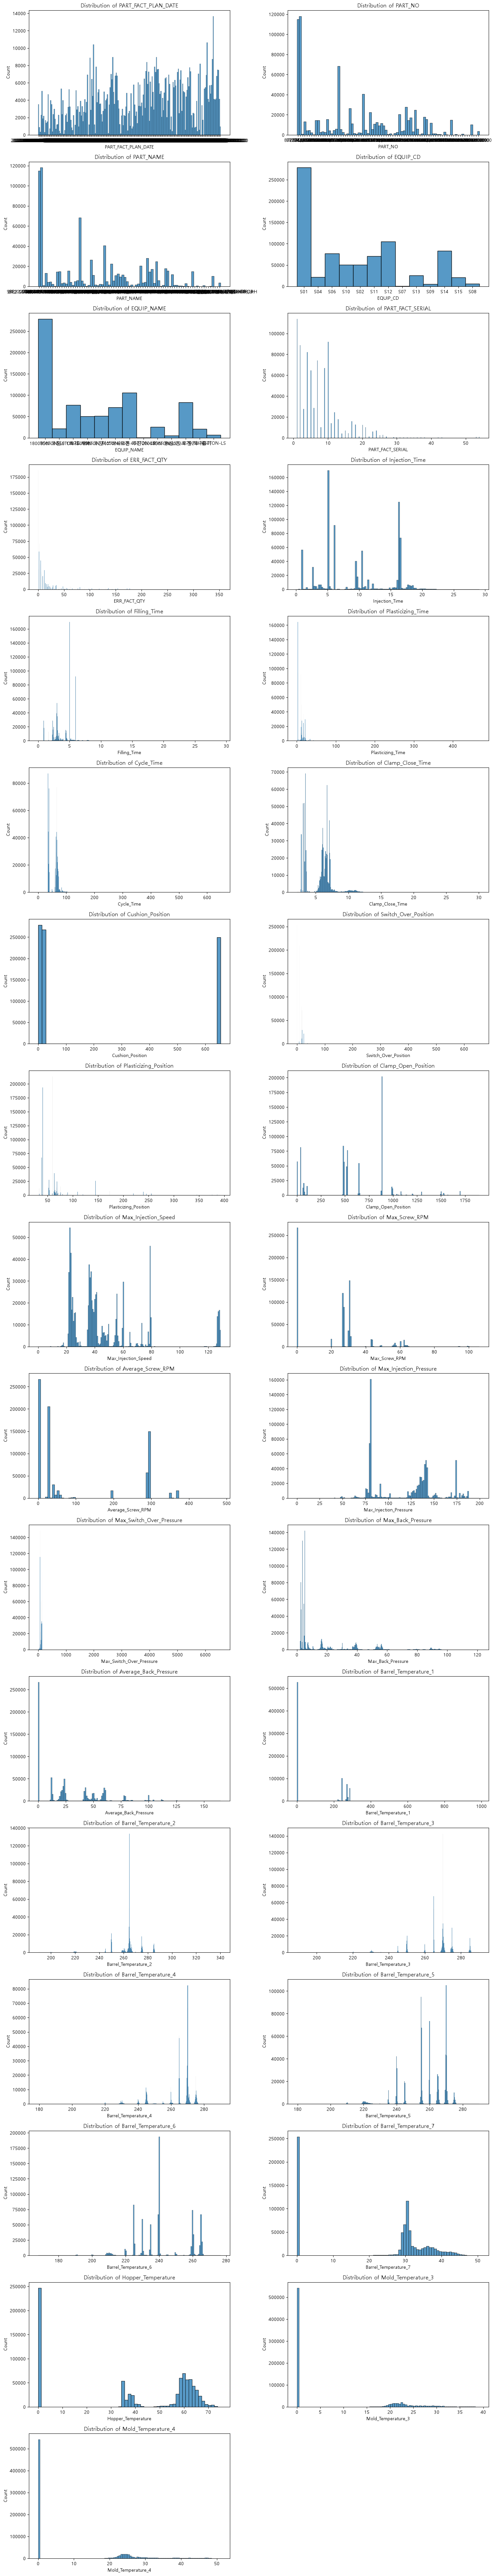

In [57]:
plot_col=cat_cols[2:] + num_cols[:26] + num_cols[28:30]
plt.figure(figsize=(15, 100))
for i, col in enumerate(plot_col): # id, timestamp 제외
    plt.subplot(22, 2, i+1)
    sns.histplot(data=unlabeled, x=col)
    plt.tight_layout()
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Count")

### 오류 7. labeled와 unlabeled의 설비·기간 불일치

기록 오류는 아니지만 **모델 적용 범위를 정하는 근거**

- labeled는 **전부 S14(650톤-우진2호기)**, unlabeled에는 S14 외에 S15·S06(550톤-도시바)·S04가 섞여 있음
- 학습 데이터가 한 건도 없는 설비에는 모델을 적용하지 않음 — 형체력이 다르면 금형 거동도 달라 이 모델의 확률에 근거가 없음
- 두 데이터의 기간이 거의 겹치지 않음(unlabeled 2020-03 ~ 10, labeled 2020-10 ~ 11)
- unlabeled를 오토인코더 정상 데이터로 끌어다 쓰려던 계획을 접은 근거 — 두 집단을 구분하는 분류기의 ROC AUC가 0.9919 (`08_Unsupervised_Defect_Scoring.ipynb` 4절에서 계산)

In [58]:
print('설비별 행 수')
for name, df in [('labeled', labeled_cn7rg3), ('unlabeled', unlabeled_cn7rg3)]:
    print(f'  {name}:', df['EQUIP_CD'].value_counts().to_dict())

print('\n기간')
for name, df in [('labeled', labeled_cn7rg3), ('unlabeled', unlabeled_cn7rg3)]:
    t=pd.to_datetime(df['TimeStamp'])
    print(f'  {name}: {t.min().date()} ~ {t.max().date()}')

설비별 행 수
  labeled: {'S14': 5230}
  unlabeled: {'S14': 71180, 'S15': 20616, 'S06': 18844, 'S04': 14391}

기간
  labeled: 2020-10-16 ~ 2020-11-06
  unlabeled: 2020-03-17 ~ 2020-10-23


## 기록 오류 보정

- `Average_Screw_RPM`이 100을 넘으면 10배로 기록된 값이므로 10으로 나눔
- 배압 쌍을 행별로 작은 값=`Average`, 큰 값=`Max`로 재배치
- 보정 후 두 쌍 모두 `Average > Max` 위반이 0이어야 함

In [59]:
model_df=labeled_cn7rg3.copy()

# 오류 3. 100 초과 값은 10배로 기록된 것
model_df['Average_Screw_RPM']=np.where(model_df['Average_Screw_RPM']>100,
                                      model_df['Average_Screw_RPM']/10,
                                      model_df['Average_Screw_RPM'])

# 오류 4. 배압 쌍을 행별 min/max로 재배치
pair=model_df[['Average_Back_Pressure', 'Max_Back_Pressure']].to_numpy()
model_df['Average_Back_Pressure']=pair.min(axis=1)
model_df['Max_Back_Pressure']=pair.max(axis=1)

print('보정 후 Average > Max 인 행')
print(' 스크류 속도:', (model_df['Average_Screw_RPM']>model_df['Max_Screw_RPM']).sum())
print(' 배압:', (model_df['Average_Back_Pressure']>model_df['Max_Back_Pressure']).sum())

보정 후 Average > Max 인 행
 스크류 속도: 0
 배압: 0


## 모델링용 데이터 저장

- 03 ~ 08에서 활용
- `Part`는 제품군(CN7/RG3)과 LH/RH를 합친 파생 변수
- `TimeStamp`, `PART_FACT_PLAN_DATE`, `PART_FACT_SERIAL`, `PART_NAME`, `EQUIP_CD`는 시간축 특성과 에피소드 분석에 필요해 유지. 모델 입력으로 쓸 때는 제외
- 인덱스는 중복 제거 직후 기준을 그대로 두므로 `index_col=0`으로 읽어야 04_6이 저장한 OOF 확률과 행이 맞음

In [60]:
drop_columns=['_id', 'EQUIP_NAME',                                       # 식별자
              'Reason',                                                  # 오류 1. 라벨 누수
              'Switch_Over_Position', 'Barrel_Temperature_7',            # 오류 2. 고정값
              'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_5',
              'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8',
              'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12',
              'Clamp_Open_Position']                                     # 오류 6. 제품 종속

model_df=model_df.drop(columns=drop_columns)

# Part: 제품군 + LH/RH (CN7LH, CN7RH, RG3LH, RG3RH)
model_df['Part']=model_df['PART_NAME'].str[:3]+model_df['PART_NAME'].str[-2:]

model_df.to_csv('labeled_modeling.csv')
print(f'{model_df.shape[0]}행 {model_df.shape[1]}컬럼 / 불량 {int(model_df["PassOrFail"].sum())}건')
print(model_df['Part'].value_counts().to_dict())
model_df.head()

5230행 30컬럼 / 불량 60건
{'CN7RH': 1989, 'CN7LH': 1985, 'RG3LH': 628, 'RG3RH': 628}


,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part
0,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.47,16.92,59.520000,...,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5,CN7RH
1,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7RH
2,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7LH
3,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7LH
4,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7RH


### unlabeled도 같은 방식으로 저장

- 08 이상치 탐지에서 unlabeled를 정상 데이터로 쓰므로 같은 보정·같은 컬럼으로 맞춰 저장
- unlabeled에는 중복이 없고 라벨(`PassOrFail`, `Reason`)도 없음. 대신 lot 불량 수량 `ERR_FACT_QTY` 유지

In [61]:
unlabeled_model_df=unlabeled_cn7rg3.copy()

# 오류 3, 4 같은 규칙으로 보정
unlabeled_model_df['Average_Screw_RPM']=np.where(unlabeled_model_df['Average_Screw_RPM']>100,
                                                 unlabeled_model_df['Average_Screw_RPM']/10,
                                                 unlabeled_model_df['Average_Screw_RPM'])

pair=unlabeled_model_df[['Average_Back_Pressure', 'Max_Back_Pressure']].to_numpy()
unlabeled_model_df['Average_Back_Pressure']=pair.min(axis=1)
unlabeled_model_df['Max_Back_Pressure']=pair.max(axis=1)

unlabeled_model_df=unlabeled_model_df.drop(columns=[c for c in drop_columns+['PART_NO']
                                                    if c in unlabeled_model_df.columns])
unlabeled_model_df['Part']=unlabeled_model_df['PART_NAME'].str[:3]+unlabeled_model_df['PART_NAME'].str[-2:]

unlabeled_model_df.to_csv('unlabeled_modeling.csv')
print(f'{unlabeled_model_df.shape[0]}행 {unlabeled_model_df.shape[1]}컬럼')
print('보정 후 Average > Max 인 행:',
      (unlabeled_model_df['Average_Screw_RPM']>unlabeled_model_df['Max_Screw_RPM']).sum(),
      (unlabeled_model_df['Average_Back_Pressure']>unlabeled_model_df['Max_Back_Pressure']).sum())
unlabeled_model_df.head()

125031행 30컬럼
보정 후 Average > Max 인 행: 0 0


,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,ERR_FACT_QTY,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part
99665,2020-03-17 04:34:55,2020-03-17 오전 12:00:00,7,"RG3 MOLD'G W/SHLD, LH",S06,135,6.0,6.0,2.9,39.1,...,0.0,264.8,269.9,270.1,260.2,239.7,60.0,0.0,0.0,RG3LH
99669,2020-03-17 04:35:34,2020-03-17 오전 12:00:00,7,"RG3 MOLD'G W/SHLD, LH",S06,135,6.0,6.0,2.8,39.2,...,0.0,264.8,269.9,270.1,260.1,239.6,59.9,0.0,0.0,RG3LH
99670,2020-03-17 04:36:13,2020-03-17 오전 12:00:00,7,"RG3 MOLD'G W/SHLD, LH",S06,135,6.0,6.0,2.9,39.2,...,0.0,264.8,270.0,270.0,260.1,239.7,59.9,0.0,0.0,RG3LH
99674,2020-03-17 04:36:52,2020-03-17 오전 12:00:00,7,"RG3 MOLD'G W/SHLD, LH",S06,135,6.0,6.0,2.8,39.1,...,0.0,264.8,270.1,270.0,260.0,239.8,59.9,0.0,0.0,RG3LH
99675,2020-03-17 04:37:31,2020-03-17 오전 12:00:00,7,"RG3 MOLD'G W/SHLD, LH",S06,135,6.0,6.0,2.8,39.1,...,0.0,264.9,270.1,270.1,259.9,240.0,59.9,0.0,0.0,RG3LH


## 정리

| 번호 | 항목 | 판정 근거 | 처리 |
| --- | --- | --- | --- |
| 1 | `Reason` | 판정 후 기록되는 값 | 입력에서 제외 (라벨 누수) |
| 2 | 고정값 컬럼 | 최빈값 비율 99% 초과 | 입력에서 제외 |
| 3 | `Average_Screw_RPM` 10배 기록 | `Average` ≤ `Max` 위반, 비율이 정확히 10배 | 100 초과를 10으로 나눔 |
| 4 | 배압 평균/최대 뒤바뀜 | `Average` ≤ `Max` 위반 | 행별 min/max로 재배치 |
| 5 | 센서 결측이 0 | 사출 중 물리적으로 불가능한 값 | 보정하지 않고 **예측 제외** |
| 6 | `Clamp_Open_Position` | `Part`에 종속, unlabeled 대부분이 학습 범위 밖 | 입력에서 제외 |
| 7 | 설비·기간 불일치 | labeled 전부 S14, 기간 거의 안 겹침 | S14만 예측 대상, unlabeled 전이 학습 보류 |

- 오류 3 보정은 **단위(mm/s)와 `Average ≤ Max` 물리 관계로 판단한 것**이며 성능을 근거로 삼지 않음
- 보정 여부가 성능에 영향을 주는지는 모델과 평가 프로토콜이 확정된 뒤에 확인함 — `09_Preprocessing_Validation`